Tree Optimization: Preparing the Medical Insurance Data
To see this in action, we will convert our insurance target (annual_medical_cost) into a binary variable (High Cost vs. Standard Cost) and prepare the features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Load dataset
df = pd.read_csv("medical_insurance.csv")

continuous_features = ["age", "income", "bmi", "visits_last_year", "risk_score", "claims_count"]
categorical_features = ["sex", "region", "urban_rural", "smoker", "plan_type"]
target_raw = "annual_medical_cost"

# Clean missing entries
df_clean = df.dropna(subset=continuous_features + categorical_features + [target_raw])

# Define binary classification target: 1 if high cost (top 25%), else 0
cost_threshold = df_clean[target_raw].quantile(0.75)
df_clean["is_high_cost"] = (df_clean[target_raw] > cost_threshold).astype(int)
y = df_clean["is_high_cost"]

# One-hot encode categorical variables
X_raw = df_clean[continuous_features + categorical_features]
X_encoded = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True).astype(float)

# Split into Train and Test sets
# Note: Decision Trees do NOT strictly require feature scaling because splits are scale-invariant!
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"✅ Data processed. Training size: {X_train.shape[0]} rows.")

✅ Data processed. Training size: 80000 rows.


Overfitting in Decision Trees and Regularization Techniques

- The Overfitting Risk: If left unconstrained, a decision tree will continue splitting until every single training observation is isolated into its own pure leaf node. The tree memorizes noise, outliers, and random fluctuations in the training set.
- Implications: While training accuracy reaches $100\%$, test accuracy drops significantly because the overly complex rules fail to generalize to unseen data.

Prevention TechniquesTo prevent overfitting, we apply structural constraints to the tree during construction:
1. max_depth: Restricts how deep the branches can grow.
2. min_samples_split: The minimum number of observations required in a node to justify making another split.
3. min_samples_leaf: The minimum number of observations required to form a terminal leaf node.

In [2]:
# Model A: Unconstrained Tree (High risk of overfitting)
overfit_tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
overfit_tree.fit(X_train, y_train)

# Model B: Regularized Tree (Constrained hyperparameters)
regularized_tree = DecisionTreeClassifier(
    criterion="entropy", 
    max_depth=4,                # Constrain vertical growth
    min_samples_split=20,       # Demand substantial proof before splitting
    min_samples_leaf=10,        # Guard against isolating single noise points
    random_state=42
)
regularized_tree.fit(X_train, y_train)

# Evaluation comparison
print("=== DECISION TREE REGULARIZATION DIAGNOSTICS ===")
print(f"Overfit Tree  | Train Acc: {accuracy_score(y_train, overfit_tree.predict(X_train)):.4f} | Test Acc: {accuracy_score(y_test, overfit_tree.predict(X_test)):.4f}")
print(f"Regularized   | Train Acc: {accuracy_score(y_train, regularized_tree.predict(X_train)):.4f} | Test Acc: {accuracy_score(y_test, regularized_tree.predict(X_test)):.4f}")

=== DECISION TREE REGULARIZATION DIAGNOSTICS ===
Overfit Tree  | Train Acc: 1.0000 | Test Acc: 0.6586
Regularized   | Train Acc: 0.7580 | Test Acc: 0.7549


 Moving to Ensemble Models: Random Forests
A Random Forest improves upon a single decision tree by building an ensemble of diverse trees and aggregating their predictions (voting for classification, averaging for regression). It minimizes overfitting through two primary mechanisms:

Bagging (Bootstrap Aggregating): Each individual tree in the forest is trained on a random sample of the data drawn with replacement from the main training set.

Feature Randomness: When splitting a node, each tree can only choose from a random subset of features rather than the entire pool. This prevents a few dominant features (like risk_score or smoker_Yes) from steering every single tree down the exact same path, ensuring the trees remain uncorrelated.

By averaging out the predictions of hundreds of uncorrelated trees, the ensemble cancels out individual tree variances while retaining predictive power.

[Image diagram showing Random Forest architecture with multiple bootstrap samples feeding into independent decision trees combined via majority voting]

 Tuning Random Forest Hyperparameters & Calculating Feature Importances
We can adjust key hyperparameters—such as n_estimators (the number of trees) and max_features (the size of the random feature subsets)—to optimize ensemble variance control.

Once trained, we can extract MDI (Mean Decrease in Impurity) Feature Importance, which calculates the total information gain contributed by each feature across all trees in the forest.


=== RANDOM FOREST PERFORMANCE SUMMARY ===
Test Accuracy : 0.7532
Test ROC-AUC   : 0.6857

Detailed Metrics Framework:
              precision    recall  f1-score   support

           0       0.76      0.99      0.86     14965
           1       0.62      0.05      0.09      5035

    accuracy                           0.75     20000
   macro avg       0.69      0.52      0.48     20000
weighted avg       0.72      0.75      0.67     20000



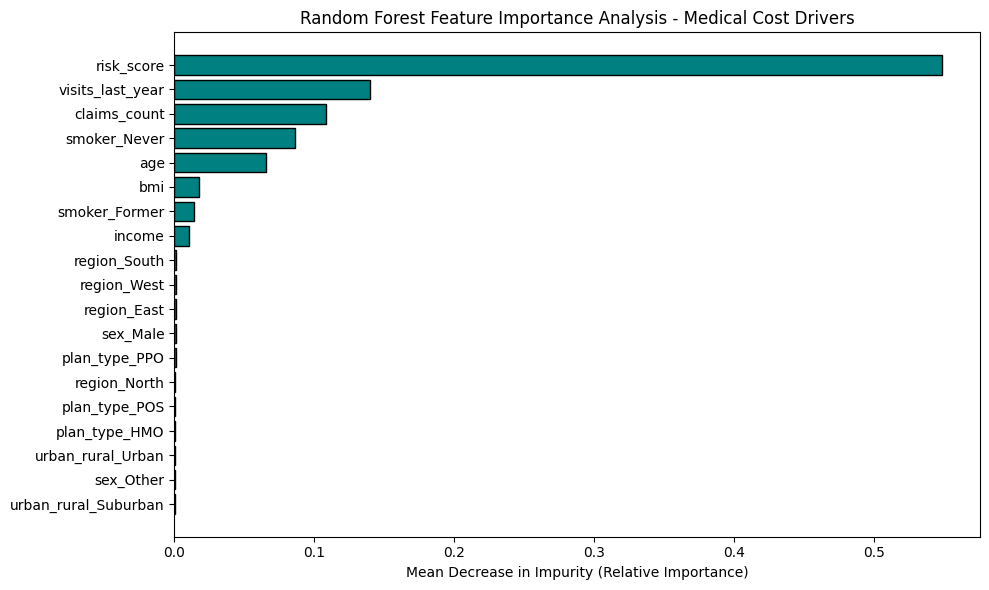


--- Top 3 Most Influential Features across the Forest ---
         Feature  Importance
      risk_score    0.548644
visits_last_year    0.140037
    claims_count    0.108309


In [3]:
# Initialize a regularized Random Forest
rf_model = RandomForestClassifier(
    n_estimators=150,       # Number of trees in the forest
    max_depth=6,            # Cap depth on individual estimators
    max_features="sqrt",    # Use square root of total features for each split
    min_samples_leaf=5,     # Prevent node overfitting
    random_state=42,
    n_jobs=-1               # Use all available CPU cores for parallel processing
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST PERFORMANCE SUMMARY ===")
print(f"Test Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"Test ROC-AUC   : {roc_auc_score(y_test, rf_probs):.4f}")
print("\nDetailed Metrics Framework:")
print(classification_report(y_test, rf_preds))

# --- Calculate and Plot Feature Importances ---
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=True) # Ascending for horizontal plot alignment

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="teal", edgecolor="black")
plt.xlabel("Mean Decrease in Impurity (Relative Importance)")
plt.title("Random Forest Feature Importance Analysis - Medical Cost Drivers")
plt.tight_layout()
plt.show()

print("\n--- Top 3 Most Influential Features across the Forest ---")
print(importance_df.tail(3).iloc[::-1].to_string(index=False))